# Stage 3 – EDA, Steps 3 and 4: Missing Values and Duplicate Records

**Project:** Machine Learning-Based U.S. Residential Rental Price Estimation System
**Continues from:** `02_eda_target.ipynb` (Step 2 – the target variable)

---

## Where we are in the EDA

Steps 1 and 2 answered two questions: *what is in each column?* and *what does the thing we are predicting look like?* We found that about 0.64% of prices are invalid and decided on a rule to remove them (\$100 to \$10,000).

This notebook answers two more questions about **data quality**. Both have to be settled **before** we split the data into training and test sets in Step 7.

**Step 3 – Missing values.** Four columns have gaps: `parking_options` (36.5% missing), `laundry_options` (20.5%), `lat`/`long` (0.5%) and `description` (2 rows). We need to know three things:

1. How much is missing, and where?
2. *Why* is it missing? Is it random, or does it follow a pattern?
3. Does the fact that a value is missing tell us something about the rent?

The answers decide how we fill the gaps later (this is called **imputation**).

**Step 4 – Duplicate records.** Step 1 found that 181,068 photos are shared by 384,977 listings, and that about 27% of descriptions are repeats. Step 2 found one absurd price (\$679,710) repeated 30 times by the same apartment complex. This strongly suggests that the same listings were posted several times. We need to measure how many duplicates there are, at several levels of strictness, and show what they would do to our test score if we left them in.

---

## Important: which rows do we use?

- **Counting** missing values and duplicates is purely descriptive, so we use **all 384,977 rows**. This matches the plan in notebook 01: data-quality checks use the full dataset.
- **Comparing prices** (for example, "is rent lower when parking is missing?") uses only the **valid-price rows** (\$100 to \$10,000). If we included the \$0 placeholders and the \$2.8 billion error, they would distort the comparison and could produce a completely false conclusion.

As in notebook 02, **no rows are deleted here**. We measure, decide, and record. The actual cleaning is done once, in a fixed order, just before the split in Step 7.

## 3.0 / 4.0 Setup

This cell does the same thing as the setup cell in notebook 02:

- `sys.path.append(...)` lets Python find our `src/` folder, because this notebook runs from inside `notebooks/`.
- `from src.utils import *` brings in the shared settings and helpers: the folder paths, `RANDOM_STATE`, `log_obs()`, `show_obs()`, `clear_obs()`, `save_fig()`, `plot_sample()`, and the confirmed price rule `PRICE_MIN` / `PRICE_MAX` from Step 2.
- `load_raw()` reads the fast parquet copy saved in notebook 01.

Two new libraries appear here:

- **missingno** draws pictures of where the missing values are. It lets you *see* whether gaps are scattered randomly or appear in blocks.
- **scikit-learn** (`train_test_split`) is used only once, in Step 4.6, to simulate a train/test split and show the effect of duplicates. The real split happens in Step 7.

Finally we create `valid`, a True/False marker for every row saying whether its price is within the Step 2 rule, and `dv` ("data, valid"), the valid-price rows we use whenever we compare prices.

In [1]:
# 3.0 Setup

%load_ext autoreload
%autoreload 2

import sys
import warnings
from pathlib import Path
sys.path.append(str(Path.cwd().parent))   # lets Python find the src/ folder

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import missingno as msno
from sklearn.model_selection import train_test_split

from src.utils import *
setup_display()
warnings.filterwarnings("ignore", category=FutureWarning)

df_raw = load_raw()
df = df_raw.copy()
df_plot = plot_sample(df)                      # 50k-row sample for charts only

valid = df["price"].between(PRICE_MIN, PRICE_MAX)   # Step 2 rule
dv = df[valid].copy()                          # valid-price rows, used for price comparisons

print(f"All rows:        {len(df):,}")
print(f"Valid-price rows: {len(dv):,}  (price ${PRICE_MIN:,} to ${PRICE_MAX:,})")
show_obs(2)                                    # Step 2 findings, to confirm the handover

All rows:        384,977
Valid-price rows: 382,494  (price $100 to $10,000)


,step,observation,evidence,decision
0,2-Target,"price is extremely right-skewed: mean $8,826 v...",2.1 summary statistics and extreme quantiles,"Describe rent with the median, not the mean; r..."
1,2-Target,"1,307 listings at $0 and 731 at $1 (2,214 belo...","2.2 threshold counts, 2.3 repeated values, 2.4...","Placeholders, not rents: remove rows with pric..."
2,2-Target,"269 listings above $10,000: a mix of genuine l...","2.2 threshold counts, 2.4 example listings, 2....","Remove rows with price > $10,000; state in the..."
3,2-Target,Some listings are properties for SALE posted i...,"2.3 repeated values (e.g. $78,500 x 25), 2.4 e...","In Step 5, search descriptions for sale wordin..."
4,2-Target,"The same absurd price $679,710 appears 30 time...","2.3 repeated values, 2.4 example listings",Evidence of one listing reposted many times; q...
5,2-Target,"Plausibility rule $100-$10,000 removes 2,483 r...",2.6 comparison of candidate rules,"Fixed domain rule (not learned from data), so ..."
6,2-Target,Log transform alone does not fix the target: l...,"2.6 comparison of candidate rules, 2.7 histograms","Filter invalid prices first, then model log1p(..."
7,2-Target,Q-Q plot: log prices follow a normal shape exc...,2.7 Q-Q plot,Re-examine very low rents with price per sqft ...
8,2-Target,Log-price deciles hold 9.1%-10.9% of valid lis...,"2.8 decile table, spiky log1p histogram in 2.7",Stratify the train/test split on log-price dec...


---

# Step 3 – Missing Values

## Background: three kinds of "missing"

Before looking at the numbers, it helps to know the three standard types of missing data. The type decides which fix is correct, and this is a common viva question.

**1. MCAR – Missing Completely At Random.** The gap has nothing to do with anything. Example: a scraper randomly failed to read the parking field on some pages. The rows with gaps are just a random subset of all rows, so filling them with the most common value, or even deleting them, does little harm.

**2. MAR – Missing At Random.** The gap depends on *other columns we can see*. Example: property managers in some states use a posting tool that skips the parking field, so parking is missing more often in those states. The gaps aren't random, but because we have the `state` column, the model can partly account for the pattern.

**3. MNAR – Missing Not At Random.** The gap depends on *the missing value itself* or on something we can't see. Example: landlords with no parking, or bad parking, leave the field blank because there is nothing good to say. The blank then means "probably poor parking", which is real information about the property, and probably about its rent.

**Why this matters:** under MAR and MNAR, filling the blanks with the most common value (e.g. "off-street parking") would be actively wrong. It would tell the model that a listing with probably-poor parking has good parking. The safer approach is to keep **"missing" as its own category**, so the model can learn for itself what a blank means.

We can't *prove* which type we have, because we never see the true missing values. But we can collect strong evidence, which is what Steps 3.1 to 3.5 do.

## 3.1 How much is missing in each column?

**What this cell does:** for every column, it counts the empty values (`isna()`) and turns the count into a percentage of all 384,977 rows. It keeps only columns that have at least one gap and draws them as a bar chart.

**Why we do it:** this is the starting point. It tells us which columns need a missing-value strategy at all, and how big the problem is. A column that is 0.001% missing needs a very different response from one that is 36% missing.

**How to read the output:** the table shows the count and percentage per column. As a rough guide:

- **under 1%:** small; almost any sensible strategy is fine;
- **around 5–30%:** needs a deliberate strategy;
- **above 30%:** large; we must be careful, because whatever we do affects a big part of the data.

Step 1 already told us which columns have gaps. Here we record the exact figures and create a chart for the report.

,missing,missing_%
parking_options,"140,687",36.544%
laundry_options,"79,026",20.527%
lat,"1,918",0.498%
long,"1,918",0.498%
description,2,0.001%


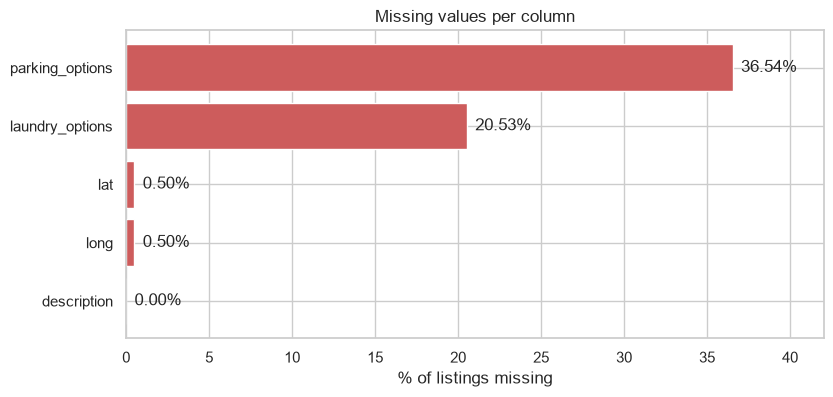

Columns with no missing values: 17 of 22


In [2]:
# 3.1 Missing values per column (all rows)

missing_table = pd.DataFrame({
    "missing": df.isna().sum(),
    "missing_%": df.isna().mean() * 100,
})
missing_table = missing_table[missing_table["missing"] > 0].sort_values("missing", ascending=False)
display(missing_table.style.format({"missing": "{:,}", "missing_%": "{:.3f}%"}))

fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(missing_table.index[::-1], missing_table["missing_%"][::-1], color="indianred")
for i, v in enumerate(missing_table["missing_%"][::-1]):
    ax.text(v + 0.5, i, f"{v:.2f}%", va="center")
ax.set(xlabel="% of listings missing", title="Missing values per column")
ax.set_xlim(0, missing_table["missing_%"].max() * 1.15)
save_fig("03_missing_per_column")
plt.show()

print("Columns with no missing values:", df.columns[df.notna().all()].size, "of", df.shape[1])

## 3.2 Where are the gaps? A picture of missingness

**What this cell does:** it draws two missingno charts, using the 50,000-row plotting sample.

**Chart 1 – the matrix.** Every column is a vertical strip and every row of the data is a thin horizontal line. Dark means a value is present; white means it's missing. We **sort the rows by state** before drawing. This is the important trick. If the gaps were completely random (MCAR), the white marks would be sprinkled evenly from top to bottom. If they depend on location (MAR), you'll see **white blocks** in some parts of the chart and dense dark parts in others, because the rows from one state sit together.

**Chart 2 – the nullity correlation heatmap.** For every pair of columns with gaps, this shows how strongly their *missingness* goes together:

- **close to +1:** when one is missing, the other is almost always missing too;
- **close to 0:** no connection;
- **negative:** when one is missing, the other tends to be present.

**Why we do it:** a single percentage (like 36.5%) hides *where* the gaps are. These two pictures give quick visual evidence about whether the gaps are random, and whether columns go missing together. For example, `lat` and `long` should show +1, because a listing either has a map pin or it doesn't. If laundry and parking also correlate, it suggests some posters fill in the details and others simply skip them.

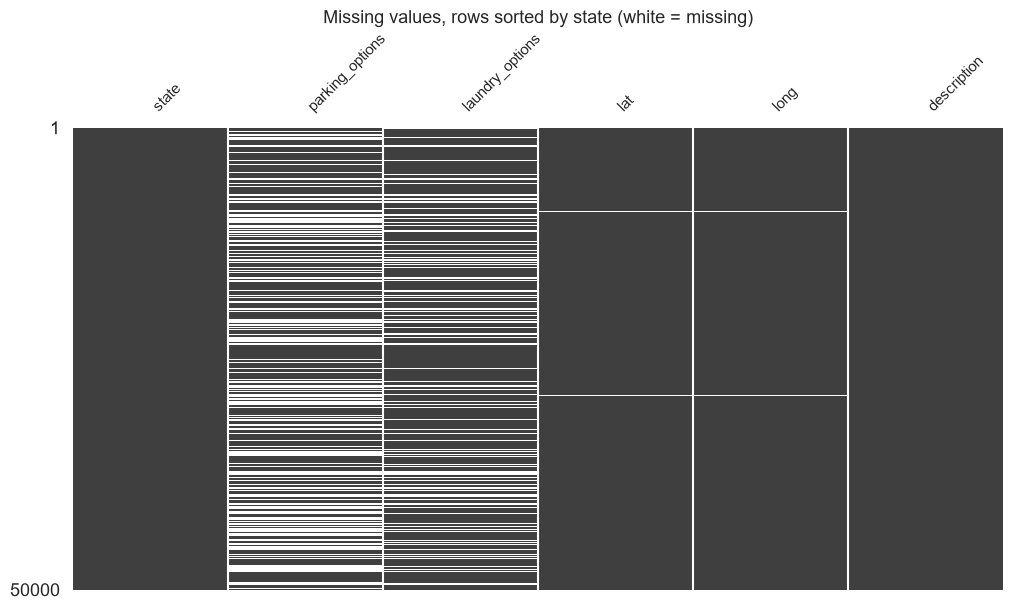

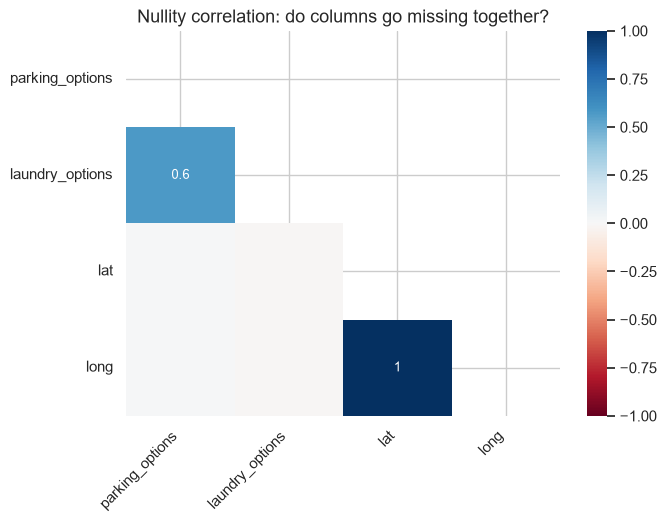

In [3]:
# 3.2 Missingness matrix (sorted by state) and nullity correlation

missing_cols = missing_table.index.tolist()
sample_sorted = df_plot.sort_values("state")[["state"] + missing_cols]

msno.matrix(sample_sorted, figsize=(12, 6), fontsize=11, sparkline=False)
plt.title("Missing values, rows sorted by state (white = missing)", fontsize=13)
save_fig("03_missing_matrix_by_state")
plt.show()

msno.heatmap(df_plot[missing_cols], figsize=(7, 5), fontsize=11)
plt.title("Nullity correlation: do columns go missing together?", fontsize=13)
save_fig("03_missing_heatmap")
plt.show()

# Findings to note: are the white marks in blocks (location-dependent) or evenly spread?
# Which pairs of columns go missing together?

## 3.3 Do laundry and parking go missing together?

**What this cell does:** the heatmap gave one correlation number. This cell makes it concrete with a **cross-table**: how many listings have both fields present, both missing, or one of each. It then compares two probabilities:

- the chance that parking is missing **when laundry is also missing**, and
- the chance that parking is missing **when laundry is present**.

It also confirms that `lat` and `long` are always missing together.

**Why we do it:** if the two probabilities are very different, the gaps are *linked*. That means they are not random coin flips on each field separately. The most likely explanation is the **poster's effort**: some landlords fill in every field, and others skip the optional details. That in turn suggests blank fields could tell us something about the *type* of landlord or listing. For example, a large managed complex with a listing template versus a private landlord posting quickly.

**How to read the output:** if parking is missing, say, 70% of the time when laundry is missing, but only 30% of the time when laundry is present, that's a strong link. If the two numbers are close, the fields go missing independently.

In [4]:
# 3.3 Co-missingness of laundry and parking

laundry_missing = df["laundry_options"].isna()
parking_missing = df["parking_options"].isna()

co_table = pd.crosstab(laundry_missing.map({True: "laundry missing", False: "laundry present"}),
                       parking_missing.map({True: "parking missing", False: "parking present"}),
                       margins=True, margins_name="total")
display(co_table.style.format("{:,}"))

p_park_given_laundry_missing = parking_missing[laundry_missing].mean() * 100
p_park_given_laundry_present = parking_missing[~laundry_missing].mean() * 100
print(f"Parking missing when laundry is missing: {p_park_given_laundry_missing:.1f}%")
print(f"Parking missing when laundry is present: {p_park_given_laundry_present:.1f}%")

latlong_together = (df["lat"].isna() == df["long"].isna()).all()
print(f"\nlat and long always missing together? {latlong_together}")

parking_options,parking missing,parking present,total
laundry_options,,,
laundry missing,"71,616","7,410","79,026"
laundry present,"69,071","236,880","305,951"
total,"140,687","244,290","384,977"


Parking missing when laundry is missing: 90.6%
Parking missing when laundry is present: 22.6%

lat and long always missing together? True


## 3.4 Does missingness depend on location or property type?

**What this cell does:** it calculates the **missing rate** (the % of listings with a blank) for parking and laundry separately **for each state** and **for each property type**. For states, it shows the 8 states with the highest and the 8 with the lowest parking-missing rates, plus the overall spread.

**Why we do it:** this is the direct test for **MAR** (missing at random, depending on other columns we can see). If gaps were completely random (MCAR), every state would have roughly the same missing rate as the national figure (about 36.5% for parking). If some states are at 10% and others at 70%, missingness clearly depends on location.

This matters for two reasons:

1. **It explains the gaps.** Different regional Craigslist sites, and the property managers who dominate them, fill in fields differently.
2. **It affects the model.** Because the model will also receive `state` and region information, it can partly learn these regional patterns. That's reassuring: the gaps aren't a hidden bias that the model has no way to understand.

**How to read the output:** look at the gap between the highest and lowest states. A wide spread is strong evidence against MCAR. For property types, check whether houses (often private landlords) have more gaps than apartments (often managed complexes that use full templates).

In [5]:
# 3.4 Missing rate by state and by property type

by_state = (df.assign(parking_missing=parking_missing, laundry_missing=laundry_missing)
              .groupby("state")[["parking_missing", "laundry_missing"]].mean() * 100)
by_state["listings"] = df["state"].value_counts()
by_state = by_state.sort_values("parking_missing", ascending=False)

fmt = {"parking_missing": "{:.1f}%", "laundry_missing": "{:.1f}%", "listings": "{:,}"}
print("States with the HIGHEST parking-missing rate")
display(by_state.head(8).style.format(fmt))
print("States with the LOWEST parking-missing rate")
display(by_state.tail(8).style.format(fmt))

state_spread = by_state["parking_missing"].agg(["min", "median", "max"])
print(f"Parking-missing rate across states: min {state_spread['min']:.1f}%, "
      f"median {state_spread['median']:.1f}%, max {state_spread['max']:.1f}%")

by_type = (df.assign(parking_missing=parking_missing, laundry_missing=laundry_missing)
             .groupby("type")[["parking_missing", "laundry_missing"]].mean() * 100)
by_type["listings"] = df["type"].value_counts()
print("\nMissing rate by property type")
display(by_type.sort_values("listings", ascending=False).style.format(fmt))

States with the HIGHEST parking-missing rate


,parking_missing,laundry_missing,listings
state,,,
md,64.7%,32.3%,"7,451"
de,63.5%,60.8%,"2,048"
fl,50.0%,25.4%,"31,929"
sc,50.0%,30.2%,"9,932"
nc,48.6%,26.4%,"18,628"
tx,48.2%,21.3%,"31,137"
ga,47.9%,31.1%,"13,841"
ky,44.8%,23.6%,"5,419"


States with the LOWEST parking-missing rate


,parking_missing,laundry_missing,listings
state,,,
id,17.4%,5.4%,"4,466"
ri,17.3%,9.9%,"1,889"
or,16.6%,7.7%,"8,079"
hi,16.5%,6.4%,"1,840"
vt,10.1%,11.4%,527
nh,8.3%,5.0%,"1,761"
wy,8.0%,8.0%,187
me,6.7%,4.5%,420


Parking-missing rate across states: min 6.7%, median 31.3%, max 64.7%

Missing rate by property type


,parking_missing,laundry_missing,listings
type,,,
apartment,39.6%,21.2%,"318,032"
house,28.2%,27.7%,"33,266"
townhouse,18.0%,5.7%,"15,885"
condo,22.1%,16.7%,"6,238"
duplex,7.6%,5.4%,"5,047"
manufactured,8.5%,3.2%,"4,242"
cottage/cabin,23.2%,10.0%,861
loft,18.0%,4.9%,693
flat,9.0%,6.8%,531


## 3.5 Is a blank field a signal about rent?

This is the most important part of Step 3. It decides whether "missing" should become its own category.

**What this cell does:** using only the valid-price rows, it splits the listings into two groups for each column with gaps (rows where the value is missing, and rows where it's present) and compares their **median rent**. It reports:

- the median rent in each group and the difference in % (the **effect size**: how big the difference is);
- a **Mann–Whitney U test** p-value (whether the difference could be due to chance).

**Why the median, not the mean?** Rents are skewed (Step 2), so a few expensive listings pull the mean around. The median is the "typical" listing and isn't affected by the tail.

**Why Mann–Whitney and not a t-test?** A t-test assumes roughly normal data, and our prices aren't normal. Mann–Whitney compares the two groups by *ranking* all the prices, so it works on skewed data.

**A warning about p-values with big data.** With around 380,000 rows, almost *any* difference, even \$5, will produce a tiny p-value ("statistically significant"). So the p-value alone tells us very little here. The **size** of the difference is what matters: a 1% gap in median rent is practically meaningless, while a 10–20% gap is a real signal. That's why the table leads with the percentage gap.

**How to read the output:** a clear gap (roughly 5% or more) for parking or laundry means blanks are **informative**: the missingness itself is linked to price. Filling blanks with the most common category would destroy that information, so "missing" should be kept as its own category.

In [6]:
# 3.5 Median rent: missing vs present (valid-price rows only)

rows = []
for col in ["parking_options", "laundry_options", "lat", "description"]:
    miss = dv[col].isna()
    price_missing, price_present = dv.loc[miss, "price"], dv.loc[~miss, "price"]
    p_value = (stats.mannwhitneyu(price_missing, price_present).pvalue
               if len(price_missing) >= 30 else np.nan)   # too few rows for a meaningful test
    rows.append({
        "column": "lat/long" if col == "lat" else col,
        "rows_missing": int(miss.sum()),
        "median_rent_missing": price_missing.median(),
        "median_rent_present": price_present.median(),
        "gap_%": (price_missing.median() / price_present.median() - 1) * 100,
        "mann_whitney_p": p_value,
    })

miss_price = pd.DataFrame(rows).set_index("column")
miss_price.style.format({
    "rows_missing": "{:,}", "median_rent_missing": "${:,.0f}", "median_rent_present": "${:,.0f}",
    "gap_%": "{:+.1f}%", "mann_whitney_p": "{:.2e}",
}, na_rep="too few rows")

# gap_% below zero means listings with the value MISSING are cheaper than those with it present.

,rows_missing,median_rent_missing,median_rent_present,gap_%,mann_whitney_p
column,,,,,
parking_options,"139,796","$1,020","$1,057",-3.5%,0.00e+00
laundry_options,"78,667","$1,010","$1,050",-3.8%,5.82e-237
lat/long,"1,908","$1,200","$1,040",+15.4%,2.04e-13
description,2,"$1,252","$1,040",+20.4%,too few rows


### 3.5 (cont.) Where does "missing" sit among the real categories?

**What this cell does:** for parking and laundry, it shows the median rent of **every** category, with the blanks shown as a category called `MISSING` (highlighted in red). The bars are sorted from cheapest to most expensive, and the number of listings is printed on each bar.

**Why we do it:** the previous table compared "missing" with "present" as one big group, but "present" mixes cheap categories (street parking) and expensive ones (attached garage). This chart shows *where* blank listings fit. Two questions to ask:

1. **Does `MISSING` behave like "no parking" / "no laundry on site"?** If blanks sit near the bottom next to the explicit "no" categories, that supports the MNAR idea that posters leave the field blank when there's nothing good to report.
2. **Is `MISSING` different from the most common category?** If it is, filling blanks with the most common value (the "mode") would move those listings into the wrong price group, which is exactly the mistake we want to avoid.

Notice that the data *already* has explicit categories "no parking" and "no laundry on site". So a blank is **not** the same as "no". It's a third state: "the poster didn't say". Keeping it separate preserves that difference.

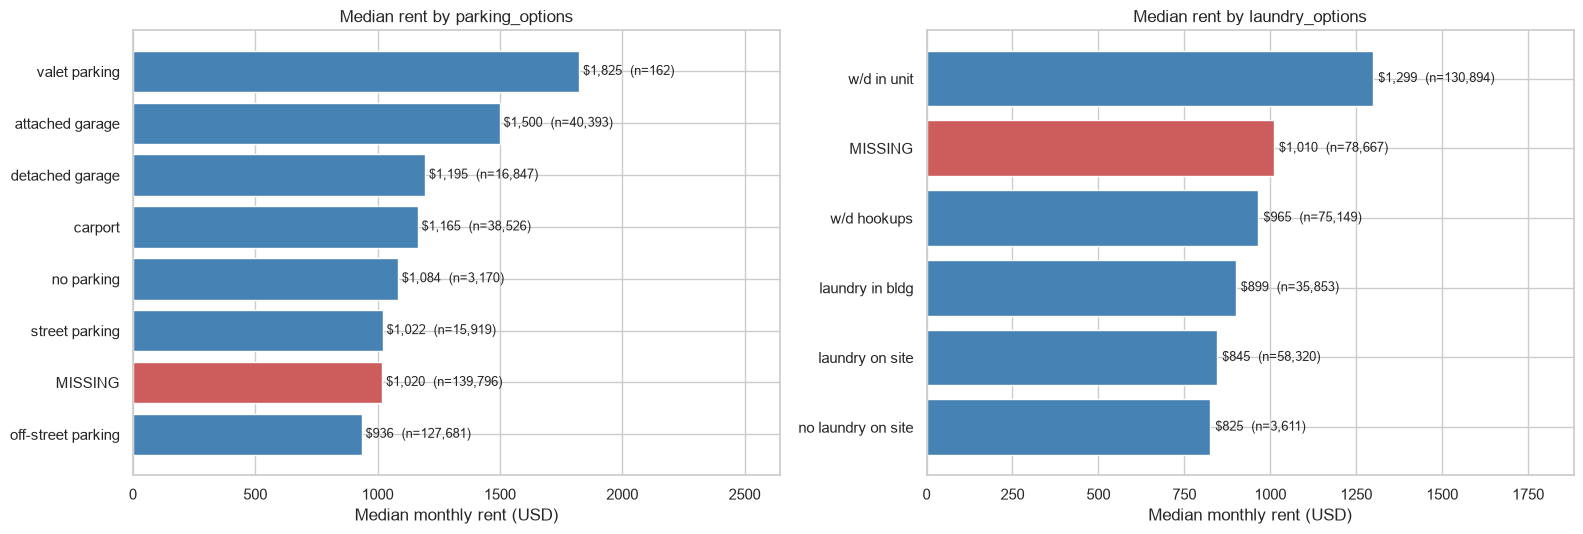

In [7]:
# 3.5 (cont.) Median rent per category, with blanks as MISSING

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))
for ax, col in zip(axes, ["parking_options", "laundry_options"]):
    summary = (dv.assign(category=dv[col].fillna("MISSING"))
                 .groupby("category")["price"].agg(["median", "count"])
                 .sort_values("median"))
    colors = ["indianred" if c == "MISSING" else "steelblue" for c in summary.index]
    ax.barh(summary.index, summary["median"], color=colors)
    for i, (med, cnt) in enumerate(zip(summary["median"], summary["count"])):
        ax.text(med + 15, i, f"${med:,.0f}  (n={cnt:,})", va="center", fontsize=9)
    ax.set_xlim(0, summary["median"].max() * 1.45)
    ax.set(title=f"Median rent by {col}", xlabel="Median monthly rent (USD)")

plt.tight_layout()
save_fig("03_median_rent_by_category_with_missing")
plt.show()

### 3.5 (cont.) Is the gap just a location effect?

**What this cell does:** it repeats the missing-vs-present comparison **inside each state separately**, then summarises the results across states. It only uses states where both groups have at least 30 listings, so each comparison is based on enough data.

**Why we do it:** this checks for a **confounding variable**, a hidden third factor that creates a misleading connection. Here's the worry. Step 3.4 may show that parking is missing more often in some states. If those happen to be cheaper states, then blank-parking listings would look cheaper nationally, *even if blanks mean nothing about the property itself*. The national gap would really be a *location* effect in disguise.

Comparing within each state removes that problem, because inside one state, location is (roughly) held constant.

**How to read the output:**

- If the gap stays in the **same direction in most states** (for example, blank-parking listings are cheaper in 40 of 48 states), the signal is genuine and not just location.
- If the direction flips from state to state and the median within-state gap is near 0%, the national gap was mostly a location effect. In that case "missing" as a category is still harmless, but we shouldn't claim that blanks carry information.

parking_options: compared in 49 states
   median within-state gap: -0.7%
   states where blanks are cheaper: 28  |  more expensive: 19

laundry_options: compared in 49 states
   median within-state gap: -2.4%
   states where blanks are cheaper: 33  |  more expensive: 16



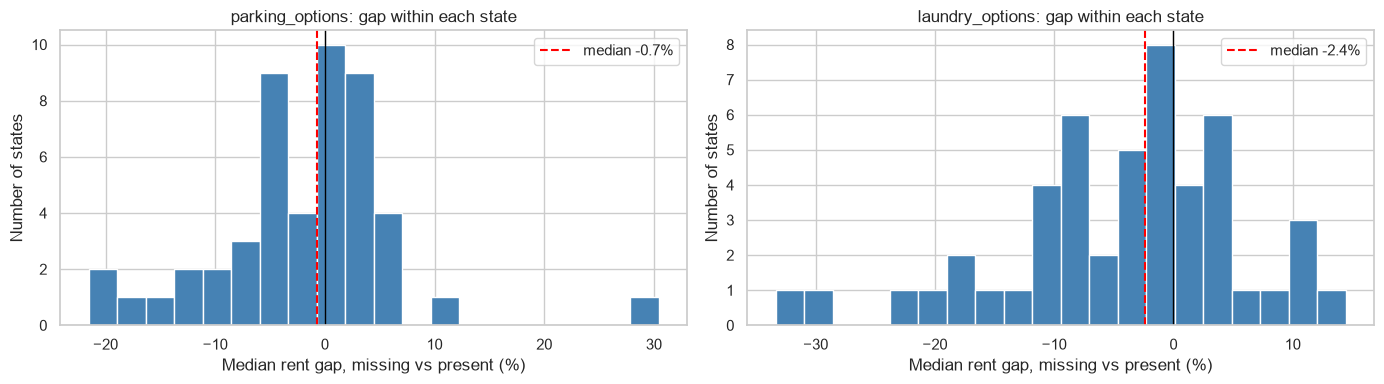

In [8]:
# 3.5 (cont.) Missing-vs-present gap within each state

def within_state_gap(col, min_rows=30):
    grouped = dv.assign(missing=dv[col].isna()).groupby(["state", "missing"])["price"]
    medians = grouped.median().unstack()
    counts = grouped.size().unstack()
    ok = (counts[True] >= min_rows) & (counts[False] >= min_rows)
    return ((medians.loc[ok, True] / medians.loc[ok, False]) - 1) * 100

state_gaps = {}
for col in ["parking_options", "laundry_options"]:
    gaps = within_state_gap(col)
    state_gaps[col] = gaps
    print(f"{col}: compared in {len(gaps)} states")
    print(f"   median within-state gap: {gaps.median():+.1f}%")
    print(f"   states where blanks are cheaper: {(gaps < 0).sum()}  |  more expensive: {(gaps > 0).sum()}\n")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, (col, gaps) in zip(axes, state_gaps.items()):
    ax.hist(gaps, bins=20, color="steelblue", edgecolor="white")
    ax.axvline(0, color="black", linewidth=1)
    ax.axvline(gaps.median(), color="red", linestyle="--", label=f"median {gaps.median():+.1f}%")
    ax.set(title=f"{col}: gap within each state", xlabel="Median rent gap, missing vs present (%)",
           ylabel="Number of states")
    ax.legend()
plt.tight_layout()
save_fig("03_missing_gap_within_state")
plt.show()

## 3.6 Missing coordinates (`lat` / `long`)

**What this cell does:** it looks at the listings with no map coordinates: how many there are, which states they come from, and whether we still know their region (`region_url`) and `state`.

**Why we do it:** location is one of the strongest drivers of rent, so we don't want to lose it. Deleting these rows is one option, since they are only about 0.5% of the data. But **the deployed system can't delete a user's request**. If the frontend ever sends a listing without exact coordinates, the model still needs a value. So we need a **filling rule**, not only a deletion rule.

The natural fill is the **typical location of that listing's region**: the median `lat` and `long` of all *training* listings from the same Craigslist site (`region_url`). A listing posted on the Denver site with no map pin gets the centre of the Denver listings. This is far better than filling with the national average, which would put it in the middle of Kansas.

**Leakage note:** the region centres must be calculated from the **training set only** and then applied to the test set. This keeps the test set completely unseen. It's done inside the preprocessing pipeline in Stage 4.

**Link to Step 5:** Step 1 found impossible coordinates (latitude 102, points in the southern hemisphere). Step 5 will turn those into missing values too, and then they get the same regional fill.

In [9]:
# 3.6 Missing coordinates

coord_missing = df["lat"].isna()
print(f"Listings without coordinates: {coord_missing.sum():,} ({coord_missing.mean() * 100:.2f}%)")
print(f"...of which region_url is known: {df.loc[coord_missing, 'region_url'].notna().mean() * 100:.1f}%")
print(f"...of which state is known:      {df.loc[coord_missing, 'state'].notna().mean() * 100:.1f}%")

print("\nStates with the most missing coordinates:")
display(df.loc[coord_missing, "state"].value_counts().head(8).rename("listings_without_coords"))

# How many regions have enough coordinates to compute a reliable centre?
coords_per_region = df.loc[~coord_missing].groupby("region_url").size()
print(f"Regions with at least 20 located listings: {(coords_per_region >= 20).sum()} of {df['region_url'].nunique()}")

Listings without coordinates: 1,918 (0.50%)
...of which region_url is known: 100.0%
...of which state is known:      100.0%

States with the most missing coordinates:


state
tx    295
fl    242
nc    138
nj    110
co    108
id    101
il     91
mi     90
Name: listings_without_coords, dtype: int64

Regions with at least 20 located listings: 406 of 413


## 3.7 Missing descriptions

**What this cell does:** it simply shows the listings with no description.

**Why it's brief:** only a couple of rows are affected, and `description` is **not a model feature**. Step 1 classified it as free text, used only to check for leakage (Step 12) and to detect duplicates (Step 4). A missing description therefore has no effect on the model, so no action is needed beyond recording it.

In [10]:
# 3.7 Missing descriptions

desc_missing = df["description"].isna()
print(f"Listings without a description: {desc_missing.sum()}")
display(df.loc[desc_missing, ["price", "type", "sqfeet", "beds", "baths", "region", "state"]])

Listings without a description: 2


,price,type,sqfeet,beds,baths,region,state
78901,905,apartment,1132,2,2.00,savannah / hinesville,ga
211266,1600,apartment,950,2,1.00,hudson valley,ny


## 3.8 Log the Step 3 observations

This cell records the Step 3 findings in the shared log (`reports/observations_log.csv`). As in notebook 02, `clear_obs("3")` first removes any older Step 3 entries, so re-running the cell replaces them rather than adding copies.

The wording of some entries is **chosen by the code from your results**. For example, if the parking gap is at least 5%, the log says blanks are *informative*; if it's smaller, it says the difference is *small*. That way the log always matches the actual numbers, and you never have to edit the text by hand.

**The decisions, in plain words:**

- **Parking and laundry:** blanks become their own category, `"missing"`, kept separate from "no parking" / "no laundry on site". In scikit-learn this is `SimpleImputer(strategy="constant", fill_value="missing")` inside the pipeline.
- **Coordinates:** filled with the median coordinates of the listing's region, learned from training data only.
- **Description:** no action, since it isn't a model feature.

In [11]:
# 3.8 Log the observations

clear_obs("3")

def gap_word(gap):
    return "informative (clear rent difference)" if abs(gap) >= 5 else "a small rent difference"

park_gap = miss_price.loc["parking_options", "gap_%"]
laun_gap = miss_price.loc["laundry_options", "gap_%"]

log_obs("3-Missing",
        f"Gaps in 4 fields only: parking {missing_table.loc['parking_options', 'missing_%']:.1f}%, "
        f"laundry {missing_table.loc['laundry_options', 'missing_%']:.1f}%, "
        f"lat/long {missing_table.loc['lat', 'missing_%']:.2f}%, description {int(desc_missing.sum())} rows",
        "3.1 missing-value table and bar chart",
        "Each field gets its own strategy (3.5-3.7); all other columns are complete")

log_obs("3-Missing",
        f"Parking is missing in {p_park_given_laundry_missing:.0f}% of rows where laundry is missing "
        f"vs {p_park_given_laundry_present:.0f}% where laundry is present; lat and long always missing together",
        "3.2 missingno heatmap, 3.3 cross-table",
        "Gaps are linked (poster effort), not independent random failures: not MCAR")

log_obs("3-Missing",
        f"Parking-missing rate ranges from {state_spread['min']:.0f}% to {state_spread['max']:.0f}% across states",
        "3.2 matrix sorted by state, 3.4 missing rate by state and type",
        "Missingness depends on location (MAR); location features help the model account for it")

for col, gap, label in [("parking_options", park_gap, "parking"), ("laundry_options", laun_gap, "laundry")]:
    gaps = state_gaps[col]
    log_obs("3-Missing",
            f"Blank {label}: median rent ${miss_price.loc[col, 'median_rent_missing']:,.0f} vs "
            f"${miss_price.loc[col, 'median_rent_present']:,.0f} when present ({gap:+.1f}%), {gap_word(gap)}; "
            f"within-state median gap {gaps.median():+.1f}%, same direction in "
            f"{int((np.sign(gaps) == np.sign(gap)).sum())} of {len(gaps)} states",
            "3.5 median comparison, category chart, within-state check",
            f"Keep blank {label} as its own 'missing' category (separate from the explicit 'no' category); "
            f"never fill with the most common value")

for col, label in [("parking_options", "parking"), ("laundry_options", "laundry")]:
    mode_cat = dv[col].mode()[0]
    mode_median = dv.loc[dv[col] == mode_cat, "price"].median()
    blank_median = miss_price.loc[col, "median_rent_missing"]
    log_obs("3-Missing",
            f"Filling blank {label} with the most common value ('{mode_cat}', median ${mode_median:,.0f}) would put "
            f"{int(miss_price.loc[col, 'rows_missing']):,} listings with median ${blank_median:,.0f} into a group "
            f"{(mode_median / blank_median - 1) * 100:+.0f}% away from their actual rent level",
            "3.5 (cont.) median rent per category",
            "Confirms mode imputation would mislabel these listings; use a separate 'missing' category")

log_obs("3-Missing",
        f"{coord_missing.sum():,} listings lack coordinates; region_url and state are always known for them",
        "3.6 coordinate checks",
        "Fill lat/long with the median coordinates of the listing's region_url, learned on training data only; "
        "regions with too few located listings fall back to the state median; "
        "invalid coordinates from Step 5 get the same treatment")

log_obs("3-Missing",
        f"{int(desc_missing.sum())} listings have no description",
        "3.7",
        "No action: description is not a model feature (used only for duplicate and leakage checks)")

show_obs(3)

,step,observation,evidence,decision
0,3-Missing,"Gaps in 4 fields only: parking 36.5%, laundry ...",3.1 missing-value table and bar chart,Each field gets its own strategy (3.5-3.7); al...
1,3-Missing,Parking is missing in 91% of rows where laundr...,"3.2 missingno heatmap, 3.3 cross-table","Gaps are linked (poster effort), not independe..."
2,3-Missing,Parking-missing rate ranges from 7% to 65% acr...,"3.2 matrix sorted by state, 3.4 missing rate b...",Missingness depends on location (MAR); locatio...
3,3-Missing,"Blank parking: median rent $1,020 vs $1,057 wh...","3.5 median comparison, category chart, within-...",Keep blank parking as its own 'missing' catego...
4,3-Missing,"Blank laundry: median rent $1,010 vs $1,050 wh...","3.5 median comparison, category chart, within-...",Keep blank laundry as its own 'missing' catego...
5,3-Missing,Filling blank parking with the most common val...,3.5 (cont.) median rent per category,Confirms mode imputation would mislabel these ...
6,3-Missing,Filling blank laundry with the most common val...,3.5 (cont.) median rent per category,Confirms mode imputation would mislabel these ...
7,3-Missing,"1,918 listings lack coordinates; region_url an...",3.6 coordinate checks,Fill lat/long with the median coordinates of t...
8,3-Missing,2 listings have no description,3.7,No action: description is not a model feature ...


---

# Step 4 – Duplicate Records

## Background: why duplicates are dangerous

Imagine preparing for an exam with a set of 100 practice questions. The real exam is supposed to test whether you understood the topic. But suppose 30 of the exam questions are *exact copies* of practice questions. You'd score very well, and the score would say you understand the topic better than you really do, because partly you're just remembering answers.

Duplicate listings do exactly this to a machine-learning model. When we split the data, copies of the same listing can land in **both** the training set (the practice questions) and the test set (the exam). The model has effectively already seen the answer for those test rows, so the **test score becomes over-optimistic**. This is a form of **data leakage**: information from the test set reaching the model during training.

It matters most for flexible models like **Random Forest** and **k-Nearest Neighbours**, which are very good at memorising individual training rows. They'll look much better on a leaky test set than they really are, which could lead us to pick the wrong model or report an unrealistic accuracy.

**Why Craigslist has so many duplicates:** posts expire after a while, so landlords repost the same listing to keep it near the top. Each repost gets a new `id` and `url`, but everything else stays the same. Large property managers also post many near-identical units from the same building.

**The rule that follows:** remove duplicates **before** splitting, so every listing can only end up on one side of the split.

## 4.1 Five levels of "duplicate"

"Duplicate" can mean different things, from very strict to very loose. We measure five levels, because each tells us something different:

| Level | Rows count as duplicates when they share... | What it catches |
|---|---|---|
| **1. Exact** | every column, including `id` | the same row saved twice by the scraper |
| **2. Reposted** | every column except `id` and `url` | the same ad reposted with a new ID; photo, text, price and details all identical |
| **3. Same text** | `description` + `price` + `region_url` | reposts where the poster changed a small detail (e.g. a flag) but kept the same text and price |
| **4. Identical to the model** | all **model features** + `price` | rows the model can't tell apart: same inputs, same answer |
| **5. Shared photo** | `image_url` only | loose; also catches different units that use the same stock photo of a building |

**What this cell does:** for each level, it reports:

- **rows_involved:** how many rows belong to a group of 2 or more copies;
- **extra_copies:** how many rows would be removed if we kept just one row from each group. This is the real "how many duplicates" number;
- **extra_%:** extra copies as a percentage of all rows.

**How it works technically:** `df.duplicated(subset=columns)` marks a row as a duplicate if an earlier row has the same values in those columns. `keep=False` marks *every* member of a group (so we can count rows involved), and `keep="first"` marks all but the first member (so we can count extra copies).

**How to read the output:** each level should find at least as many duplicates as the stricter level above it (levels 3 and 4 look at different columns, so they aren't strictly ordered). Level 1 should be zero, because Step 1 proved every `id` is unique. Level 4 is the one that matters most for the model; level 5 is evidence only.

In [12]:
# 4.1 Duplicates at five levels (all rows)

binary_cols = ["cats_allowed", "dogs_allowed", "smoking_allowed",
               "wheelchair_access", "electric_vehicle_charge", "comes_furnished"]

# The columns the model will actually use (identifiers and free text excluded, region_url as location key)
MODEL_FEATURES = ["region_url", "state", "type", "sqfeet", "beds", "baths", *binary_cols,
                  "laundry_options", "parking_options", "lat", "long"]

dup_levels = {
    "1. Exact (all columns)": df.columns.tolist(),
    "2. Reposted (all but id, url)": [c for c in df.columns if c not in ["id", "url"]],
    "3. Same text (description + price + site)": ["description", "price", "region_url"],
    "4. Identical to the model (features + price)": MODEL_FEATURES + ["price"],
    "5. Shared photo (image_url)": ["image_url"],
}

rows = []
for level, cols in dup_levels.items():
    involved = df.duplicated(subset=cols, keep=False)
    extra = df.duplicated(subset=cols, keep="first")
    rows.append({"level": level, "rows_involved": int(involved.sum()),
                 "extra_copies": int(extra.sum()), "extra_%": extra.mean() * 100})

dup_table = pd.DataFrame(rows).set_index("level")
dup_table.style.format({"rows_involved": "{:,}", "extra_copies": "{:,}", "extra_%": "{:.2f}%"})

,rows_involved,extra_copies,extra_%
level,,,
1. Exact (all columns),0,0,0.00%
"2. Reposted (all but id, url)","65,007","46,544",12.09%
3. Same text (description + price + site),"109,901","85,512",22.21%
4. Identical to the model (features + price),"234,823","191,384",49.71%
5. Shared photo (image_url),"258,634","203,909",52.97%


## 4.2 What does a reposted listing look like?

**What this cell does:** it finds the **largest group of level-2 duplicates** (reposted listings) and shows its rows side by side: the `id`, the `url`, and a few key details.

**Why we do it:** numbers in a table are convincing, but one real example is much easier to explain in a report or viva. It shows that these are *genuinely the same listing*: identical price, size, location and description, differing only in `id` and `url`. That is exactly what reposting looks like.

**How it works technically:** `pd.util.hash_pandas_object` turns each row's selected columns into a single number (a "fingerprint"). Identical rows get identical fingerprints, so counting fingerprints finds the biggest group quickly without comparing long text columns directly.

In [13]:
# 4.2 Example of a reposted listing

repost_cols = dup_levels["2. Reposted (all but id, url)"]
fingerprint = pd.util.hash_pandas_object(df[repost_cols], index=False)
biggest = fingerprint.value_counts()
print(f"Largest repost group: {biggest.iloc[0]} copies of the same listing")
print(f"Repost groups with 2+ copies: {(biggest >= 2).sum():,}\n")

example = df.loc[fingerprint == biggest.index[0],
                 ["id", "url", "price", "type", "sqfeet", "beds", "baths", "region", "state", "description"]].head(6).copy()
example["description"] = example["description"].str.slice(0, 70)
with pd.option_context("display.max_colwidth", 80):
    display(example)

Largest repost group: 141 copies of the same listing
Repost groups with 2+ copies: 18,463



,id,url,price,type,sqfeet,beds,baths,region,state,description
360047,7049992542,https://littlerock.craigslist.org/apa/d/sherwood-jacksonville-sherwood-2-and...,525,manufactured,800,2,1.00,little rock,ar,"*** show contact info *** REMODELED 2BR, 1BA AND OTHERS FOR RENT. CONT"
360697,7049992330,https://littlerock.craigslist.org/apa/d/sherwood-jacksonville-sherwood-2-and...,525,manufactured,800,2,1.00,little rock,ar,"*** show contact info *** REMODELED 2BR, 1BA AND OTHERS FOR RENT. CONT"
362024,7049992063,https://littlerock.craigslist.org/apa/d/sherwood-jacksonville-sherwood-2-and...,525,manufactured,800,2,1.00,little rock,ar,"*** show contact info *** REMODELED 2BR, 1BA AND OTHERS FOR RENT. CONT"
364521,7049991766,https://littlerock.craigslist.org/apa/d/sherwood-jacksonville-sherwood-2-and...,525,manufactured,800,2,1.00,little rock,ar,"*** show contact info *** REMODELED 2BR, 1BA AND OTHERS FOR RENT. CONT"
364644,7049989052,https://littlerock.craigslist.org/apa/d/sherwood-jacksonville-sherwood-2-and...,525,manufactured,800,2,1.00,little rock,ar,"*** show contact info *** REMODELED 2BR, 1BA AND OTHERS FOR RENT. CONT"
364676,7049988179,https://littlerock.craigslist.org/apa/d/sherwood-jacksonville-sherwood-2-and...,525,manufactured,800,2,1.00,little rock,ar,"*** show contact info *** REMODELED 2BR, 1BA AND OTHERS FOR RENT. CONT"


## 4.3 Which listings are copied the most?

**What this cell does:** it groups rows that are **identical to the model** (level 4: same features and same price) and lists the 10 biggest groups, with their region, type, size and price.

**Why we do it:** it shows *who* creates the duplicates. If the biggest groups are all apartments from large managed complexes, the duplication comes from property managers posting many identical units or reposting on a schedule. This also connects to Step 2, where one complex posted the same absurd price 30 times.

**An honest caveat for the report:** some level-4 groups may be **genuinely different apartments** in the same building, with the same floor plan and rent. They're real units, not repost errors. But from the model's point of view they are *identical rows*: same inputs, same answer. Keeping 50 copies wouldn't teach the model anything new. It would only (a) make that one building count 50 times more than a typical listing, and (b) cause the leakage shown in 4.4. So removing them is still the right choice, and we can explain why even if some are real separate units.

In [14]:
# 4.3 Largest groups of rows that are identical to the model

group_sizes = (df.groupby(MODEL_FEATURES + ["price"], dropna=False).size()
                 .rename("copies").sort_values(ascending=False))
top_groups = group_sizes.head(10).reset_index()[["copies", "price", "type", "sqfeet", "beds", "baths", "region_url", "state"]]
display(top_groups)

size_dist = group_sizes.value_counts().sort_index()
print(f"Distinct listings (as the model sees them): {len(group_sizes):,}")
print(f"Listings that appear exactly once:          {size_dist.get(1, 0):,}")
print(f"Groups with 10 or more copies:              {(group_sizes >= 10).sum():,}")

,copies,price,type,sqfeet,beds,baths,region_url,state
0,578,615,apartment,364,0,1.00,https://amarillo.craigslist.org,tx
1,365,730,apartment,750,1,1.00,https://beaumont.craigslist.org,tx
2,295,625,apartment,644,1,1.00,https://winstonsalem.craigslist.org,nc
3,270,600,apartment,480,0,1.00,https://kansascity.craigslist.org,ks
4,246,795,apartment,1248,3,2.00,https://winstonsalem.craigslist.org,nc
5,228,795,townhouse,1200,3,1.50,https://ksu.craigslist.org,ks
6,220,521,apartment,595,1,1.00,https://albanyga.craigslist.org,ga
7,160,725,apartment,770,2,1.00,https://winstonsalem.craigslist.org,nc
8,160,1025,apartment,900,1,1.00,https://lancaster.craigslist.org,pa
9,155,1259,townhouse,1353,3,2.00,https://fredericksburg.craigslist.org,va


Distinct listings (as the model sees them): 193,593
Listings that appear exactly once:          150,154
Groups with 10 or more copies:              5,006


## 4.4 Proof: what duplicates do to a test set

This is the key piece of evidence for Step 4. It shows the leakage problem with real numbers instead of just describing it.

**What this cell does:** it simulates the train/test split we'll do in Step 7 (80% training, 20% test, same random seed), three times:

1. **No deduplication:** split the valid-price rows as they are.
2. **After removing reposts (level 2):** remove exact reposts first, then split.
3. **After removing model-identical rows (level 4):** remove all rows the model can't tell apart, then split.

Each time, it measures the **% of test rows that have an identical twin in the training set**, meaning a training row with exactly the same features *and* the same price. For those test rows, the model has literally seen the answer during training.

**How to read the output:** in scenario 1, expect a large share of test rows to have a twin in training. That's the leakage. Scenario 2 should reduce it, and scenario 3 brings it to **exactly 0%**, because after level-4 deduplication no two rows are identical, so no test row can have a twin.

**Why this is strong evidence:** it turns "duplicates might inflate the score" into "X% of our test set would have been answers the model had already seen". That single number justifies the deduplication decision, and it's worth quoting directly in the report.

(This is a simulation only. The real split, with stratification on the price deciles from Step 2, happens in Step 7.)

,rows_before_split,test_rows_with_twin_in_train_%
scenario,,
1. No deduplication,"382,494",58.90%
2. Reposts removed (level 2),"336,209",51.60%
3. Model-identical rows removed (level 4),"192,470",0.00%


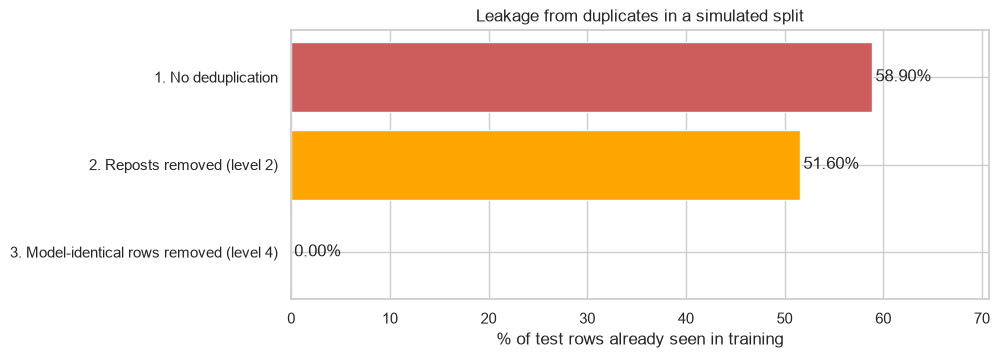

In [15]:
# 4.4 Simulated split: share of test rows with an identical twin in training

twin_key = MODEL_FEATURES + ["price"]

def twin_share(data):
    train_idx, test_idx = train_test_split(data.index, test_size=0.2, random_state=RANDOM_STATE)
    fp = pd.util.hash_pandas_object(data[twin_key], index=False)
    train_prints = set(fp.loc[train_idx])
    return fp.loc[test_idx].isin(train_prints).mean() * 100, len(data)

scenarios = {
    "1. No deduplication": dv,
    "2. Reposts removed (level 2)": dv.drop_duplicates(subset=repost_cols),
    "3. Model-identical rows removed (level 4)": dv.drop_duplicates(subset=twin_key),
}

leak_rows = []
for name, data in scenarios.items():
    share, n = twin_share(data)
    leak_rows.append({"scenario": name, "rows_before_split": n, "test_rows_with_twin_in_train_%": share})
leak_table = pd.DataFrame(leak_rows).set_index("scenario")
display(leak_table.style.format({"rows_before_split": "{:,}", "test_rows_with_twin_in_train_%": "{:.2f}%"}))

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.barh(leak_table.index[::-1], leak_table["test_rows_with_twin_in_train_%"][::-1],
        color=["seagreen", "orange", "indianred"])
for i, v in enumerate(leak_table["test_rows_with_twin_in_train_%"][::-1]):
    ax.text(v + 0.3, i, f"{v:.2f}%", va="center")
ax.set(xlabel="% of test rows already seen in training", title="Leakage from duplicates in a simulated split")
ax.set_xlim(0, max(leak_table["test_rows_with_twin_in_train_%"].max() * 1.2, 1))
save_fig("04_duplicate_leakage_simulation")
plt.show()

## 4.5 Log the Step 4 observations

Same approach as 3.8: `clear_obs("4")` clears old Step 4 entries, then the findings are logged with the numbers filled in from your results.

**The decisions, in plain words:**

- **Remove rows that are identical to the model (level 4), keeping one of each.** This removes reposts (level 2) automatically as well, and it's the level that guarantees zero overlap between training and test.
- **Do it before the split, and after the price filter.** The final cleaning order in Step 7 will be: (1) remove invalid prices (Step 2 rule), (2) fix or remove impossible values (Step 5), (3) remove duplicates, (4) split. Duplicates are removed after the other fixes because fixing a value can create new identical rows.
- **Shared photos (level 5) are evidence only.** Different real units often use the same building photo, so the photo alone isn't a safe reason to delete a row.

In [16]:
# 4.5 Log the observations

clear_obs("4")

def dup(level_prefix, field):
    row = dup_table[dup_table.index.str.startswith(level_prefix)].iloc[0]
    return row[field]

log_obs("4-Duplicates",
        f"No exact duplicate rows ({int(dup('1.', 'extra_copies'))}); every id is unique",
        "4.1 level 1",
        "Exact-duplicate removal alone would miss the problem; check looser levels")

log_obs("4-Duplicates",
        f"{int(dup('2.', 'extra_copies')):,} extra copies ({dup('2.', 'extra_%'):.2f}%) are reposts: identical except "
        f"id and url; largest group has {int(biggest.iloc[0])} copies",
        "4.1 level 2, 4.2 example group",
        "Remove reposts before the train/test split")

log_obs("4-Duplicates",
        f"{int(dup('4.', 'extra_copies')):,} extra copies ({dup('4.', 'extra_%'):.2f}%) are identical to the model "
        f"(same features and price); {int((group_sizes >= 10).sum()):,} groups have 10+ copies",
        "4.1 level 4, 4.3 largest groups",
        "Deduplicate on model features + price, keeping one row per group (also removes all reposts)")

log_obs("4-Duplicates",
        f"Without deduplication, {leak_table.iloc[0, 1]:.1f}% of test rows have an identical twin in training "
        f"(simulated 80/20 split); {leak_table.iloc[1, 1]:.1f}% after removing reposts; "
        f"{leak_table.iloc[2, 1]:.1f}% after level-4 deduplication",
        "4.4 leakage simulation",
        "Deduplicate BEFORE splitting to prevent leakage and an over-optimistic test score")

log_obs("4-Duplicates",
        f"{int(dup('5.', 'extra_copies')):,} listings reuse a photo from another listing",
        "4.1 level 5",
        "Evidence only: different real units can share a building photo, so photo alone is not a deletion rule")

log_obs("4-Duplicates",
        "Cleaning order matters: fixing values can create new identical rows",
        "Reasoning from Steps 2-5",
        "Step 7 order: price rule -> validity fixes (Step 5) -> deduplication -> stratified split")

log_obs("4-Duplicates",
        f"Level-4 deduplication removes {(1 - leak_table.iloc[2, 0] / leak_table.iloc[0, 0]) * 100:.0f}% of valid rows: "
        f"{leak_table.iloc[0, 0]:,} become {leak_table.iloc[2, 0]:,}",
        "4.4 rows_before_split",
        "Still ample for all five models; from Step 6 on, EDA of relationships uses valid, deduplicated rows "
        "so large complexes with hundreds of copies don't dominate the charts")

show_obs(4)

,step,observation,evidence,decision
0,4-Duplicates,No exact duplicate rows (0); every id is unique,4.1 level 1,Exact-duplicate removal alone would miss the p...
1,4-Duplicates,"46,544 extra copies (12.09%) are reposts: iden...","4.1 level 2, 4.2 example group",Remove reposts before the train/test split
2,4-Duplicates,"191,384 extra copies (49.71%) are identical to...","4.1 level 4, 4.3 largest groups","Deduplicate on model features + price, keeping..."
3,4-Duplicates,"Without deduplication, 58.9% of test rows have...",4.4 leakage simulation,Deduplicate BEFORE splitting to prevent leakag...
4,4-Duplicates,"203,909 listings reuse a photo from another li...",4.1 level 5,Evidence only: different real units can share ...
5,4-Duplicates,Cleaning order matters: fixing values can crea...,Reasoning from Steps 2-5,Step 7 order: price rule -> validity fixes (St...
6,4-Duplicates,Level-4 deduplication removes 50% of valid row...,4.4 rows_before_split,Still ample for all five models; from Step 6 o...



---

## Steps 3 and 4 – Summary of findings

### Step 3: Missing values

| Finding | Evidence | Decision |
|---|---|---|
| Only 4 fields have gaps: parking 36.5%, laundry 20.5%, lat/long 0.5%, description 2 rows | 3.1 | Each field gets its own strategy; the other 17 columns are complete |
| When laundry is blank, parking is blank **90.6%** of the time, vs 22.6% when laundry is filled in | 3.3 | Gaps are linked: some posters skip optional details altogether. Not MCAR |
| Parking-missing rate ranges from **6.7% (Maine) to 64.7% (Maryland)**; apartments 39.6% vs duplexes 7.6% | 3.2, 3.4 | Missingness depends on location and type (MAR) |
| Nationally, blank-parking listings are 3.5% cheaper and blank-laundry listings 3.8% cheaper | 3.5 | Small differences; p-values are tiny only because of the sample size |
| **Within states**, the parking gap almost disappears (−0.7%, cheaper in 28 states, dearer in 19); laundry −2.4% (33 vs 16) | 3.5 (cont.) | Most of the national gap is a *location* effect, not information carried by the blank |
| Blanks sit **mid-range** among the real categories, not beside "no parking" / "no laundry on site" | 3.5 (cont.) chart | No evidence that a blank secretly means "no amenity" |
| The most common laundry value is "w/d in unit" (median \$1,299); blank-laundry listings have median \$1,010 | 3.5 (cont.) chart | Mode imputation would give 78k listings the most expensive laundry label. Use a `"missing"` category |
| 1,918 listings have no coordinates; their region and state are always known; 406 of 413 regions have 20+ located listings | 3.6 | Fill with the region's median coordinates (training data only); fall back to the state median for sparse regions |
| 2 listings have no description | 3.7 | No action (not a model feature) |

**How to explain Step 3 in one paragraph:** the gaps are not random. They depend on where the listing was posted and on how much detail the poster bothered to give. However, once location is taken into account, a blank field tells us very little extra about the rent. So we don't claim blanks are a strong predictor. Instead we keep "missing" as its own category because the alternative, filling with the most common value, would actively mislabel tens of thousands of listings (for laundry, with the most expensive option). The model can then decide for itself how much the blank matters.

### Step 4: Duplicate records

| Finding | Evidence | Decision |
|---|---|---|
| No exact duplicate rows: every `id` is unique | 4.1 | Exact-duplicate checks alone would miss the problem |
| **46,544** extra copies (12.1%) are pure reposts; the largest group is one Little Rock listing posted **141 times** | 4.1, 4.2 | Remove before splitting |
| **85,512** extra copies (22.2%) share the same text, price and site | 4.1 | Reposts with small edits |
| **191,384** extra copies (**49.7%**) are identical to the model; the biggest group is **578** identical Amarillo studios at \$615 | 4.1, 4.3 | Deduplicate on model features + price, keeping one row per group |
| In a simulated 80/20 split, **58.9%** of test rows have an identical twin in training. Removing reposts only cuts this to 51.6%; level-4 deduplication cuts it to **0%** | 4.4 | Deduplicate at level 4, before the split |
| Deduplication halves the valid data: 382,494 → 192,470 rows | 4.4 | Still ample for all five models |

**The most important result of the whole EDA so far:** without deduplication, more than half of the test set would be listings the model had already seen during training. Any accuracy we reported would mostly measure memory, not prediction. Random Forest and k-NN would look especially (and misleadingly) good, because they are the best at memorising rows. The 4.4 chart is worth putting in the report.

**Alternative we considered:** a *group-aware split* (scikit-learn's `GroupShuffleSplit`), which keeps all copies but puts every copy of a listing on the same side of the split. It also prevents leakage. We chose deduplication instead because group splitting still lets a complex with 578 copies count 578 times in training and in the test score, so a few large property managers would dominate what the model learns and how it's judged. Deduplication gives each distinct listing one vote.

**Consequence for the rest of the EDA:** the charts and medians in Steps 2 and 3 were calculated before deduplication, so large complexes had extra weight in them. The conclusions still hold, because they are about clear patterns rather than exact values. But from Step 6 onward, when we study relationships between features and rent, we'll use the valid, deduplicated rows.


---

## What's next: Step 5 – Validity checks (`04_eda_validity.ipynb`)

Steps 3 and 4 dealt with values that are *absent* or *repeated*. Step 5 deals with values that are **present but impossible**. Step 1 already spotted several:

- `sqfeet` of 0, and a maximum of 8,388,607 (a system placeholder, 2²³ − 1);
- 1,100 bedrooms and 75 bathrooms;
- latitude 102 (impossible, since latitude stops at 90) and points in the southern hemisphere;
- the `state` column not matching the coordinates (Reno listings labelled `ca`).

Step 5 will also follow up two leads from Step 2:

- **sale listings** hiding inside the valid price range (searching descriptions for sale wording);
- the **heavy lower tail** of rents between about \$100 and \$250, checked with **price per square foot**.